In [1]:
import pandas as pd
import numpy as np

In [5]:
app = pd.read_csv("Contacts/application_train.csv")
bureau = pd.read_csv("Contacts/bureau.csv")
cc_summary = pd.read_csv("Contacts/credit_card_summary.csv")
inst_summary = pd.read_csv("Contacts/installment_summary.csv")
pos_cash_summary = pd.read_csv("Contacts/pos_cash_summary.csv")
prev_app = pd.read_csv("Contacts/previous_application.csv")

In [9]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Working,Single / not married,Laborers,1.0,2
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Married,Core staff,2.0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Working,Single / not married,Laborers,1.0,2
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Working,Civil marriage,Laborers,2.0,2
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Working,Single / not married,Core staff,1.0,2


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

Object `default` not found.


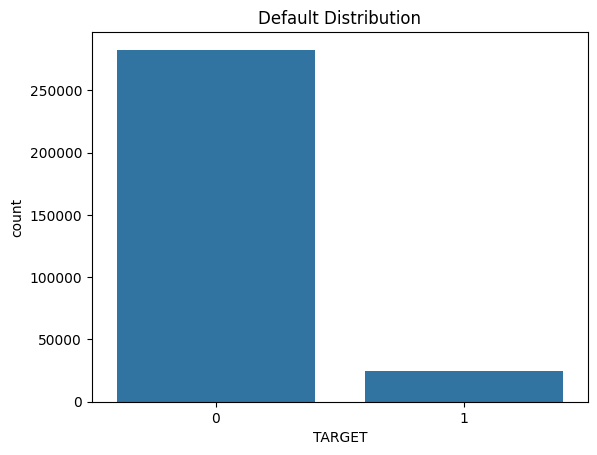

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [11]:
Q.1] What percentage of customers default?

sns.countplot(x='TARGET',data=app)
plt.title("Default Distribution")
plt.show()

app['TARGET'].value_counts()


In [12]:
default_rate = 24825 / (282686 + 24825)
print(default_rate * 100)

8.072881945686495


In [ ]:
# Only around 8% of customers default, indicating that the dataset is highly imbalanced with most customers repaying their loans.

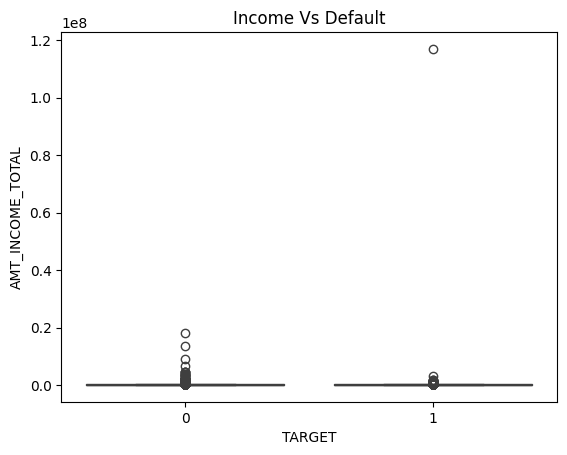

In [13]:
# Q.2] Do low-income customers default more?

sns.boxplot(x='TARGET',y='AMT_INCOME_TOTAL',data=app)
plt.title("Income Vs Default")
plt.show()

In [ ]:
# Customers with lower income tend to show slightly higher default rates. However,
there is significant overlap between defaulters and non-defaulters, indicating that income alone is not a strong predictor.

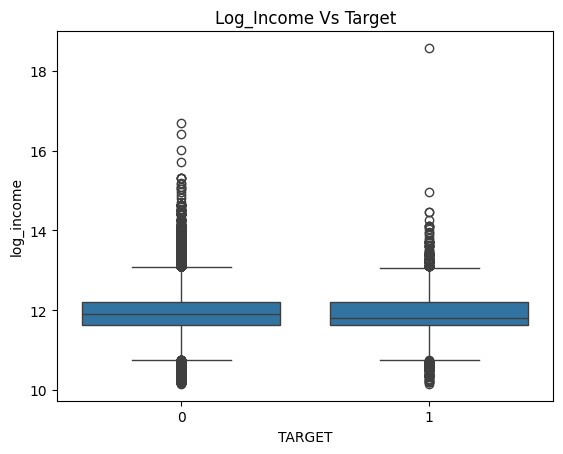

In [14]:
import numpy as np

app['log_income'] = np.log1p(app['AMT_INCOME_TOTAL'])

sns.boxplot(x='TARGET',y='log_income',data=app)
plt.title("Log_Income Vs Target")
plt.show()

In [ ]:
# After applying log transformation, the income distribution becomes more normalized, 
making comparison between groups easier. Despite this, both groups still show overlap.

In [15]:
app.groupby('TARGET')['AMT_INCOME_TOTAL'].mean()

TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64

In [ ]:
# Customers with lower income tend to have higher default probability.

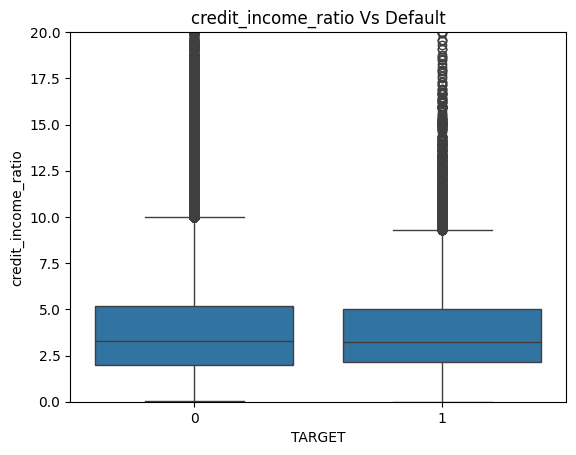

In [18]:
# 3. Credit vs Income (Risk Ratio)
# Does higher loan burden increase default?

app['credit_income_ratio'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']

sns.boxplot(x='TARGET',y='credit_income_ratio',data=app)
plt.ylim(0, 20)
plt.title("credit_income_ratio Vs Default")
plt.show()

In [ ]:
# Defaulters have a higher credit-to-income ratio, 
suggesting that customers with higher financial burden are more likely to default.

In [19]:
app.groupby('TARGET')['AMT_CREDIT'].mean()

TARGET
0    602648.282002
1    557778.527674
Name: AMT_CREDIT, dtype: float64

In [ ]:
# Higher credit amounts are typically granted to financially stable customers, which explains the lower default rate in that segment.

In [22]:
app['CREDIT_BIN'] = pd.qcut(app['AMT_CREDIT'], 5)
app.groupby('CREDIT_BIN')['TARGET'].mean()

CREDIT_BIN
(44999.999, 254700.0]    0.072376
(254700.0, 432000.0]     0.091724
(432000.0, 604152.0]     0.100549
(604152.0, 900000.0]     0.078549
(900000.0, 4050000.0]    0.060752
Name: TARGET, dtype: float64

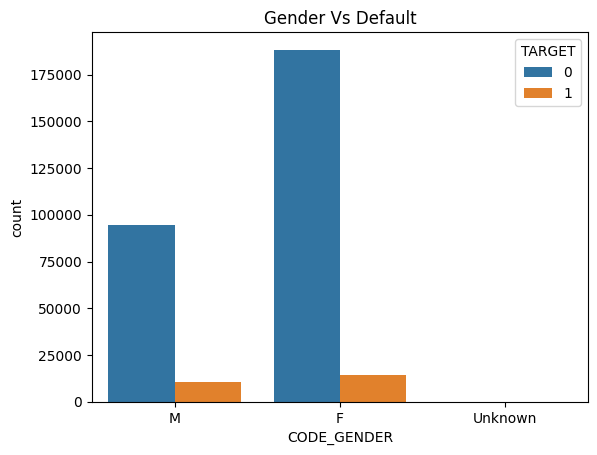

In [23]:
# Question 4: Does Gender Impact Default?
# Do male and female customers have different default behavior?

sns.countplot(x='CODE_GENDER',hue='TARGET',data=app)
plt.title("Gender Vs Default")
plt.show()

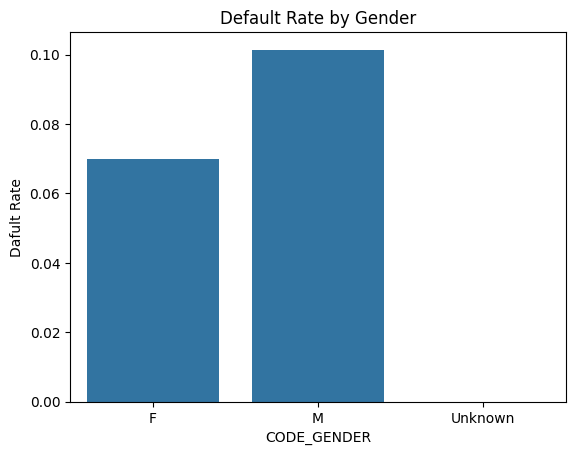

In [24]:
gender_default = app.groupby('CODE_GENDER')['TARGET'].mean().reset_index()

sns.barplot(x='CODE_GENDER',y='TARGET',data=gender_default)
plt.title("Default Rate by Gender")
plt.ylabel("Dafult Rate")
plt.show()

In [ ]:
# Male customers had a slightly higher default rate of around 10% compared to females at around 7%. However,
# the difference is moderate, so gender is not a strong standalone predictor of default.

In [25]:
app.groupby('CODE_GENDER')['TARGET'].mean()

CODE_GENDER
F          0.069993
M          0.101419
Unknown    0.000000
Name: TARGET, dtype: float64

In [ ]:
# Default rates vary across genders, indicating demographic impact on credit risk.

In [27]:
final_agg = app.merge(inst_summary, on='SK_ID_CURR', how='left') \
               .merge(cc_summary, on='SK_ID_CURR', how='left') \
               .merge(pos_cash_summary, on='SK_ID_CURR', how='left')

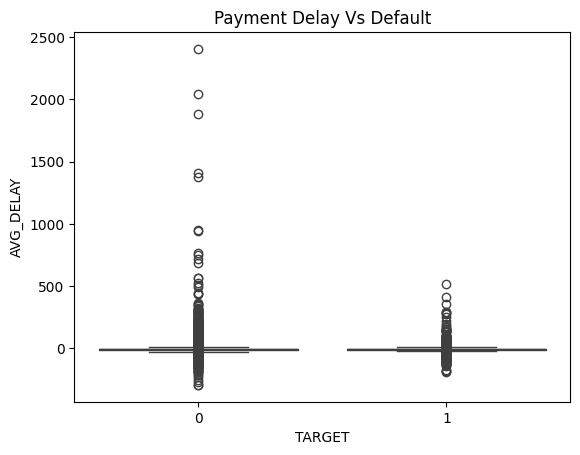

In [29]:
# 1. Payment Behavior

sns.boxplot(x='TARGET',y='AVG_DELAY',data=final_agg)
plt.title("Payment Delay Vs Default")
plt.show()

In [ ]:
# Payment delay shows significant variability across both default and non-default groups, with substantial overlap. 
# While extreme delays are observed, average delay alone may not fully capture default behavior, 
# indicating the need for more granular payment features.

In [32]:
final_agg['late_flag'] = final_agg['AVG_DELAY'].apply(lambda x: 1 if x > 0 else 0)

In [33]:
final_agg['high_delay'] = final_agg['AVG_DELAY'].apply(lambda x: 1 if x > 30 else 0)

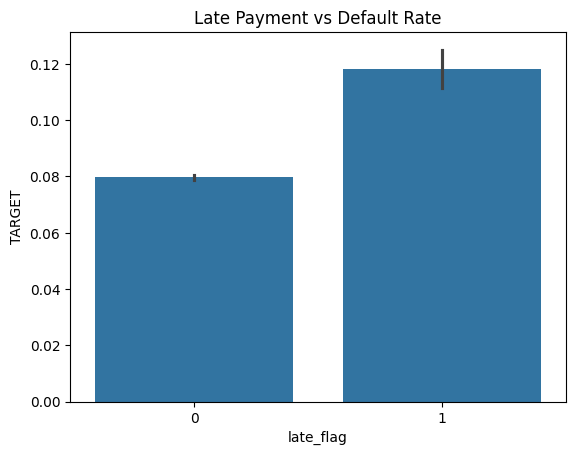

In [34]:
sns.barplot(x='late_flag',y='TARGET',data=final_agg)
plt.title("Late Payment vs Default Rate")
plt.show()

In [ ]:
# Customers with late payment behavior exhibit a significantly higher default rate (~12%) compared to those who pay on time (~8%),
# indicating that payment discipline is a strong predictor of credit risk.

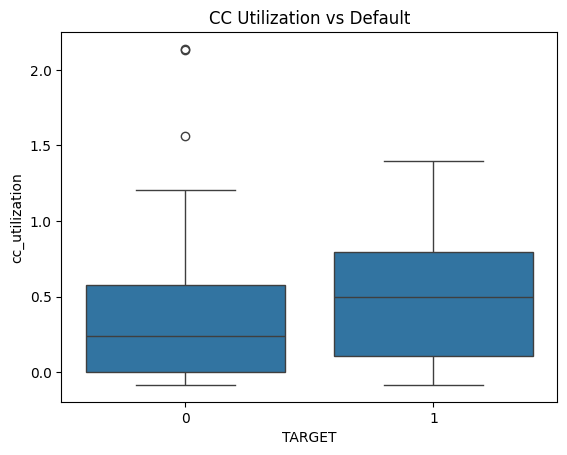

In [35]:
# q.2] Credit Card Utilization

final_agg['cc_utilization'] = final_agg['AVG_BALANCE'] / final_agg['AVG_CREDIT_LIMIT']

sns.boxplot(x='TARGET',y='cc_utilization',data=final_agg)
plt.title("CC Utilization vs Default")
plt.show()

In [ ]:
# Customers with higher credit card utilization exhibit a significantly higher likelihood of default. 
# The default group shows a higher median and overall distribution,
# indicating that excessive usage of available credit is a strong indicator of financial stress.

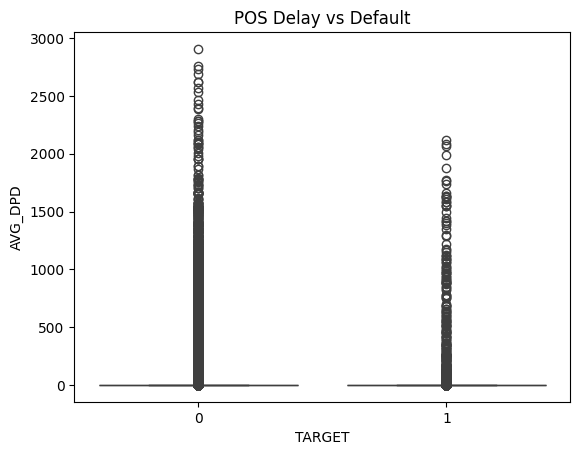

In [36]:
sns.boxplot(x='TARGET',y='AVG_DPD',data=final_agg)
plt.title("POS Delay vs Default")
plt.show()

In [37]:
final_agg['pos_late_flag'] = final_agg['AVG_DPD'].apply(lambda x: 1 if x > 0 else 0)

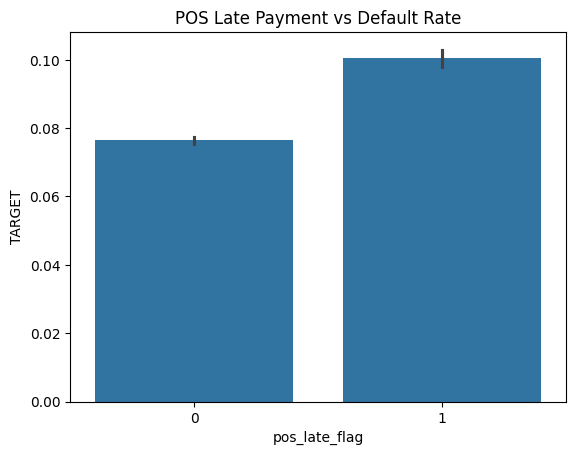

In [38]:
sns.barplot(x='pos_late_flag', y='TARGET', data=final_agg)
plt.title("POS Late Payment vs Default Rate")
plt.show()

In [ ]:
# Customers with any POS payment delay exhibit higher default rates (~10%) compared to those with no delay (~7.6%),
# indicating that even minor delays are associated with increased credit risk.

In [39]:
final_agg['high_pos_delay'] = final_agg['AVG_DPD'].apply(lambda x: 1 if x > 30 else 0)

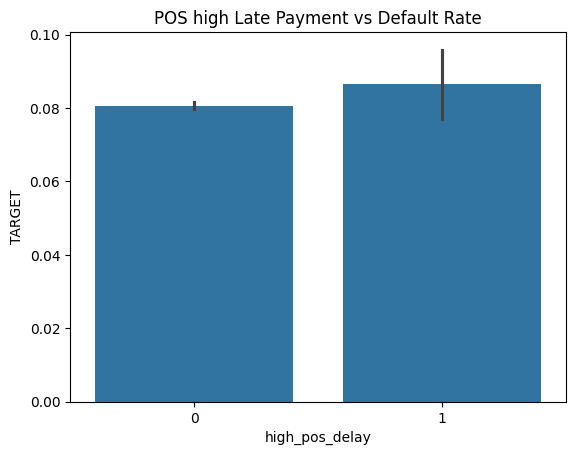

In [40]:
sns.barplot(x='high_pos_delay', y='TARGET', data=final_agg)
plt.title("POS high Late Payment vs Default Rate")
plt.show()

In [ ]:
# Customers with high POS delays show slightly higher default rates; however, the difference is marginal, 
# suggesting that extreme delay thresholds may not significantly enhance predictive power.

In [45]:
final_agg['emi_income_ratio'] = final_agg['AMT_ANNUITY'] / final_agg['AMT_INCOME_TOTAL']

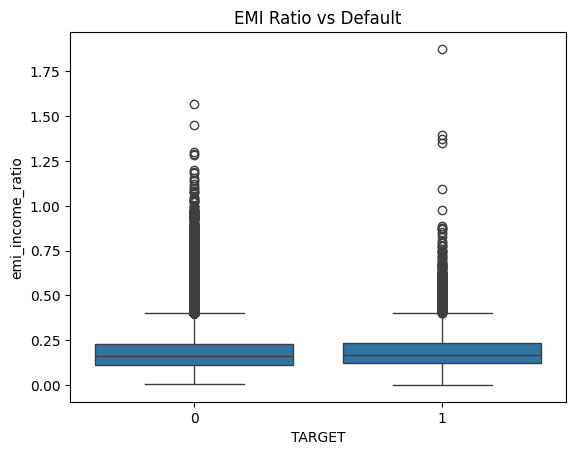

In [46]:
sns.boxplot(x='TARGET',y='emi_income_ratio',data=final_agg)
plt.title("EMI Ratio vs Default")
plt.show()

In [ ]:
# People who have higher EMI compared to income are more likely to default.

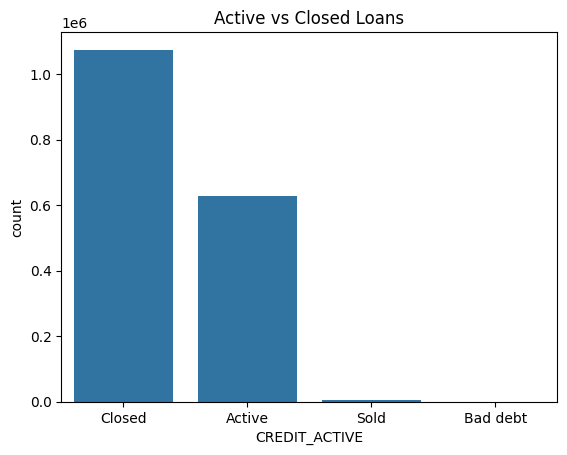

In [47]:
# Active vs Closed Loans
# Do customers with active loans have higher risk?

sns.countplot(x='CREDIT_ACTIVE', data=bureau)
plt.title("Active vs Closed Loans")
plt.show()

In [ ]:
# The majority of bureau loans are closed, indicating that many customers have prior borrowing experience and repayment history.
# However, a significant number of active loans suggest ongoing financial obligations, which may increase credit risk.
# A small proportion of bad debt cases represents highly risky customers.

In [48]:
bureau_active = bureau[bureau['CREDIT_ACTIVE'] == 'Active'] \
    .groupby('SK_ID_CURR').size().reset_index(name='active_loans')

final_agg = final_agg.merge(bureau_active, on='SK_ID_CURR', how='left')

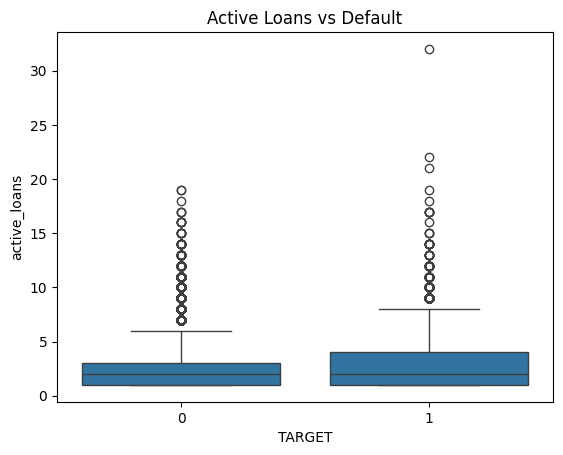

In [49]:
sns.boxplot(x='TARGET', y='active_loans', data=final_agg)
plt.title("Active Loans vs Default")
plt.show()

In [ ]:
# Customers with a higher number of active loans are more likely to default.
# The default group shows a higher median and greater variability,
# indicating that multiple ongoing financial obligations increase credit risk.

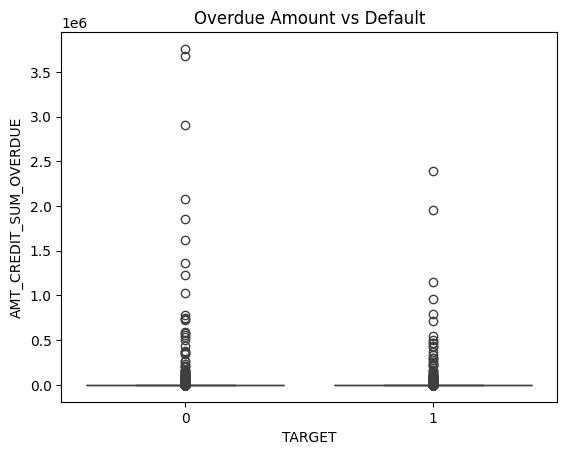

In [50]:
bureau_overdue = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_OVERDUE'].sum().reset_index()

final_agg = final_agg.merge(bureau_overdue, on='SK_ID_CURR', how='left')

sns.boxplot(x='TARGET', y='AMT_CREDIT_SUM_OVERDUE', data=final_agg)
plt.title("Overdue Amount vs Default")
plt.show()

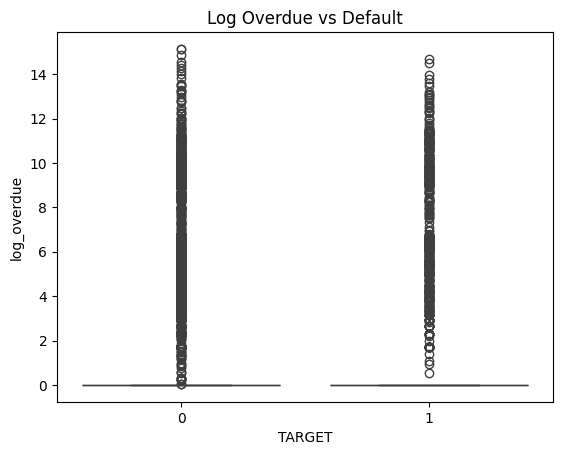

In [51]:

final_agg['log_overdue'] = np.log1p(final_agg['AMT_CREDIT_SUM_OVERDUE'])

sns.boxplot(x='TARGET', y='log_overdue', data=final_agg)
plt.title("Log Overdue vs Default")
plt.show()

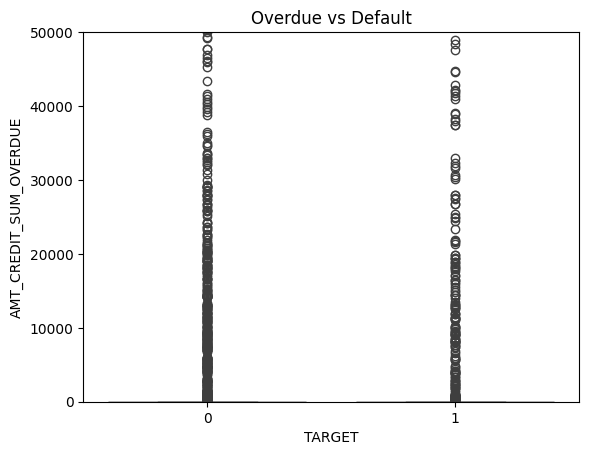

In [53]:
sns.boxplot(x='TARGET', y='AMT_CREDIT_SUM_OVERDUE', data=final_agg)
plt.ylim(0, 50000)
plt.title("Overdue vs Default")
plt.show()

In [ ]:
# Overdue amount directly reflects missed payments and is one of the most critical indicators of credit risk. 
# Customers with consistently high overdue balances should be flagged as high-risk

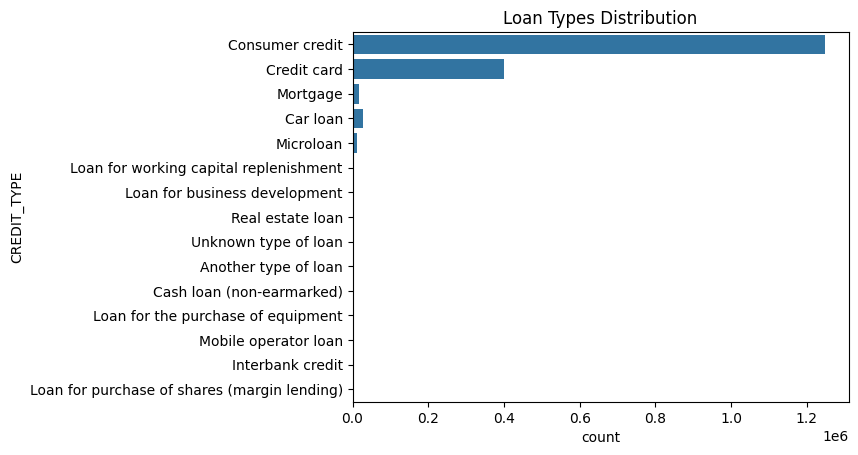

In [56]:
sns.countplot(y='CREDIT_TYPE', data=bureau)
plt.title("Loan Types Distribution")
plt.show()

In [ ]:
# consumer credit and credit card most common loan type

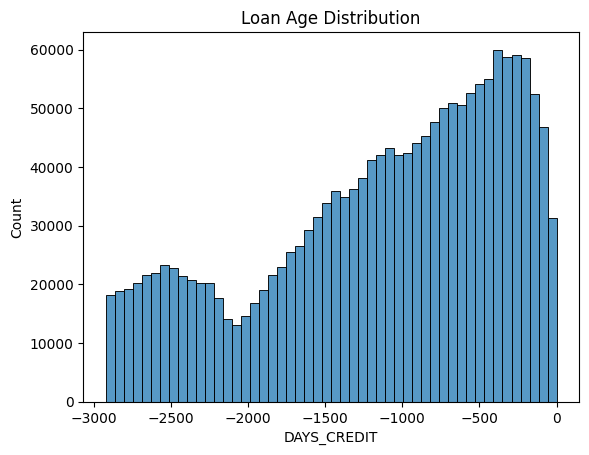

In [58]:
sns.histplot(bureau['DAYS_CREDIT'],bins=50)
plt.title("Loan Age Distribution")
plt.show()

In [ ]:
# ✔ Most customers have taken recent loans (last ~1–2 years)
# ✔ Number of loans decreases as we go further into the past
# ✔ Indicates increasing credit activity in recent years
# ✔ Dataset is skewed toward recent borrowing behavior

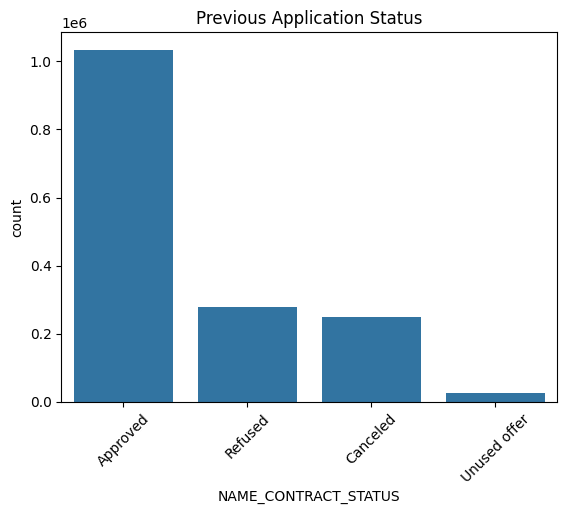

In [60]:
# 1. Application Status (Approved vs Refused)
# Do rejected customers have higher risk?

sns.countplot(x='NAME_CONTRACT_STATUS', data=prev_app)
plt.xticks(rotation=45)
plt.title("Previous Application Status")
plt.show()


In [ ]:
# The distribution shows that while most applications are approved, 
# there is still a substantial proportion of refused and canceled applications. 
# This indicates a diverse customer base with varying credit risk levels,
# where a significant segment faces rejection or does not complete the loan process.

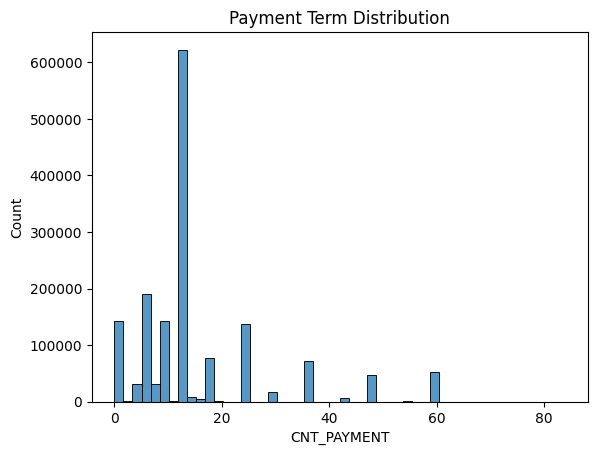

In [65]:
sns.histplot(prev_app['CNT_PAYMENT'], bins=50)
plt.title("Payment Term Distribution")
plt.show()

In [ ]:
# The distribution of payment terms shows that most loans are structured around standard durations, 
# with 12 months being the most common. Short to medium-term loans dominate, while long-term loans are relatively rare,
# indicating a preference for shorter repayment periods in the dataset.

In [66]:
# Contract Status vs Default

prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': 'mean',
    'AMT_CREDIT': 'mean',
    'CNT_PAYMENT': 'mean',
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Refused').sum()
}).reset_index()

prev_agg.rename(columns={
    'NAME_CONTRACT_STATUS': 'refused_count'
}, inplace=True)

In [67]:
final_agg = final_agg.merge(prev_agg, on='SK_ID_CURR', how='left')

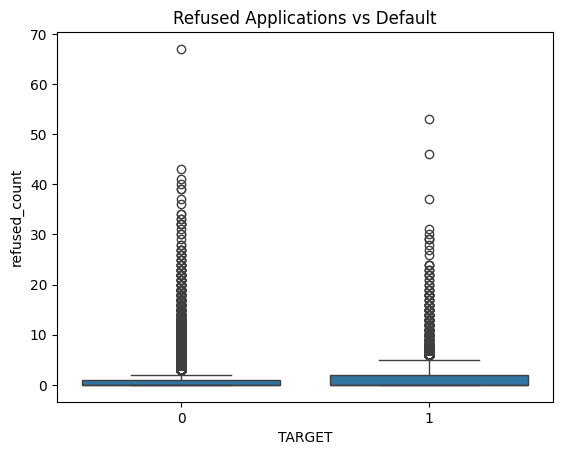

In [68]:
sns.boxplot(x='TARGET', y='refused_count', data=final_agg)
plt.title("Refused Applications vs Default")
plt.show()

In [ ]:
# Customers who have a higher number of previously refused applications show a significantly greater likelihood of default.
# In contrast, non-defaulters typically have very few or no past refusals,
# indicating that past rejection history is a strong indicator of credit risk.

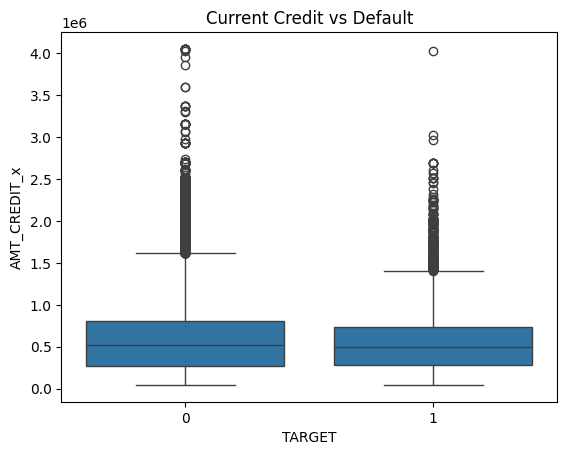

In [74]:
# Previous Loan Amount vs Default

sns.boxplot(x='TARGET', y='AMT_CREDIT_x', data=final_agg)
plt.title("Current Credit vs Default")
plt.show()

In [ ]:
# Both defaulters and non-defaulters have similar current loan amounts. 
#There is no strong difference between the two groups, which means current credit amount alone is not a strong factor to predict default.

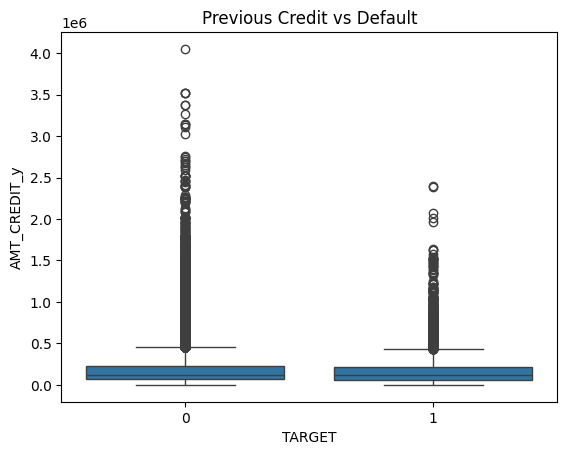

In [75]:
sns.boxplot(x='TARGET', y='AMT_CREDIT_y', data=final_agg)
plt.title("Previous Credit vs Default")
plt.show()

In [ ]:
# Previous loan amounts are also similar for both defaulters and non-defaulters. 
# This suggests that past credit amount does not clearly differentiate risky customers.